In [2]:
!pip install yfinance

In [3]:
import pandas as pd
import numpy as np
import matplotlib as mp # Visualisation package
import statsmodels as ss # Statistical Analysis package
import os # Read/Save files to/from device
import yfinance as yf # Yahoo Finance Package
import time # The time.sleep(2 ** attempt) function implements exponential backoff

In [4]:
#Define your 3 companies and the Index
tickers_list = ['SGRO.L', 'LAND.L', 'BLND.L', '^FTSE']

In [5]:
#DEFINE TIME PERIOD & EXTRACT HISTORICAL DATA 
alldata = yf.download(tickers_list, start='2022-01-03', end='2024-02-03')
print("Extracting Data")

[*********************100%***********************]  4 of 4 completed

Extracting Data


In [6]:
download_folder = os.path.join(os.path.expanduser("~"), "Downloads")

In [7]:
csv_file = os.path.join(download_folder, "data_2022_2024.csv")

In [8]:
alldata.to_csv(csv_file)
print(f"save the raw data: {csv_file}")

save the raw data: /Users/rachelnguyen/Downloads/data_2022_2024.csv


In [9]:
xlsx_file = os.path.join(download_folder, "data_2022_2024.xlsx")

In [10]:
alldata.to_excel(xlsx_file)

print(f"save the raw data: {xlsx_file}")

save the raw data: /Users/rachelnguyen/Downloads/data_2022_2024.xlsx


In [11]:
#Read CSV with multi-level headers
all_data = pd.read_csv(csv_file, header=[0, 1], index_col=0)

In [12]:
# Extract only the Close prices for all companies
# We drop Open, High, Low, Volume as per the tutorial instructions
closing_prices = all_data['Close']

In [13]:
# Drop any rows with missing data (NaN) just to be safe
closing_prices = closing_prices.dropna()

In [14]:
# Find the total number of rows (trading days)
total_days = len(closing_prices)
print(f"Total trading days available: {total_days}")

Total trading days available: 525


In [15]:
download_folder = os.path.join(os.path.expanduser("~"), "Downloads")

In [16]:
#Save the completely Close prices dataframe
csv_file = os.path.join(download_folder, "ClosePrices.csv")
excel_file = os.path.join(download_folder, "ClosePrices.xlsx")

closing_prices.to_csv(csv_file)
closing_prices.to_excel(excel_file)
print("Close prices successfully saved to CSV and Excel formats")

Close prices successfully saved to CSV and Excel formats


In [17]:
# Split into Training Set and Test Set
# The assignment requires the last 20 days as the Test Set
split_point = total_days - 20

In [18]:
# Training Set: From the beginning up to the split point
training_set = closing_prices.iloc[0:split_point]

In [19]:
# Test Set: From the split point to the end (exactly 20 days)
test_set = closing_prices.iloc[split_point:total_days]

print("\n--- DATA SPLIT COMPLETE ---")
print(f"Training set has {len(training_set)} days (From {training_set.index[0]} to {training_set.index[-1]})")
print(f"Test set has {len(test_set)} days (From {test_set.index[0]} to {test_set.index[-1]})")


--- DATA SPLIT COMPLETE ---
Training set has 505 days (From 2022-01-04 to 2024-01-05)
Test set has 20 days (From 2024-01-08 to 2024-02-02)


In [20]:
# Display the Test Set to verify
print("Test Set (Last 20 days):")
print(test_set.head())

Test Set (Last 20 days):
Ticker          BLND.L      LAND.L      SGRO.L        ^FTSE
Date                                                       
2024-01-08  399.943726  697.857361  877.662537  7694.200195
2024-01-09  398.345947  696.060303  868.472412  7684.000000
2024-01-10  395.150421  689.271423  870.470215  7651.799805
2024-01-11  394.950684  683.480774  869.471375  7576.600098
2024-01-12  401.541534  683.680542  871.069580  7624.899902


In [21]:
train_csv_file = os.path.join(download_folder, "TrainingSet.csv")
train_excel_file = os.path.join(download_folder, "TrainingSet.xlsx")

test_csv_file = os.path.join(download_folder, "TestSet.csv")
test_excel_file = os.path.join(download_folder, "TestSet.xlsx")

In [22]:
# Save Training set in both CSV and Excel formats
training_set.to_csv(train_csv_file)
training_set.to_excel(train_excel_file)

# Save Test set in both CSV and Excel formats
test_set.to_csv(test_csv_file)
test_set.to_excel(test_excel_file)

print("Training and Test sets successfully saved")

Training and Test sets successfully saved


Đã lưu ảnh: /Users/rachelnguyen/Downloads/Max_Min_Chart.png


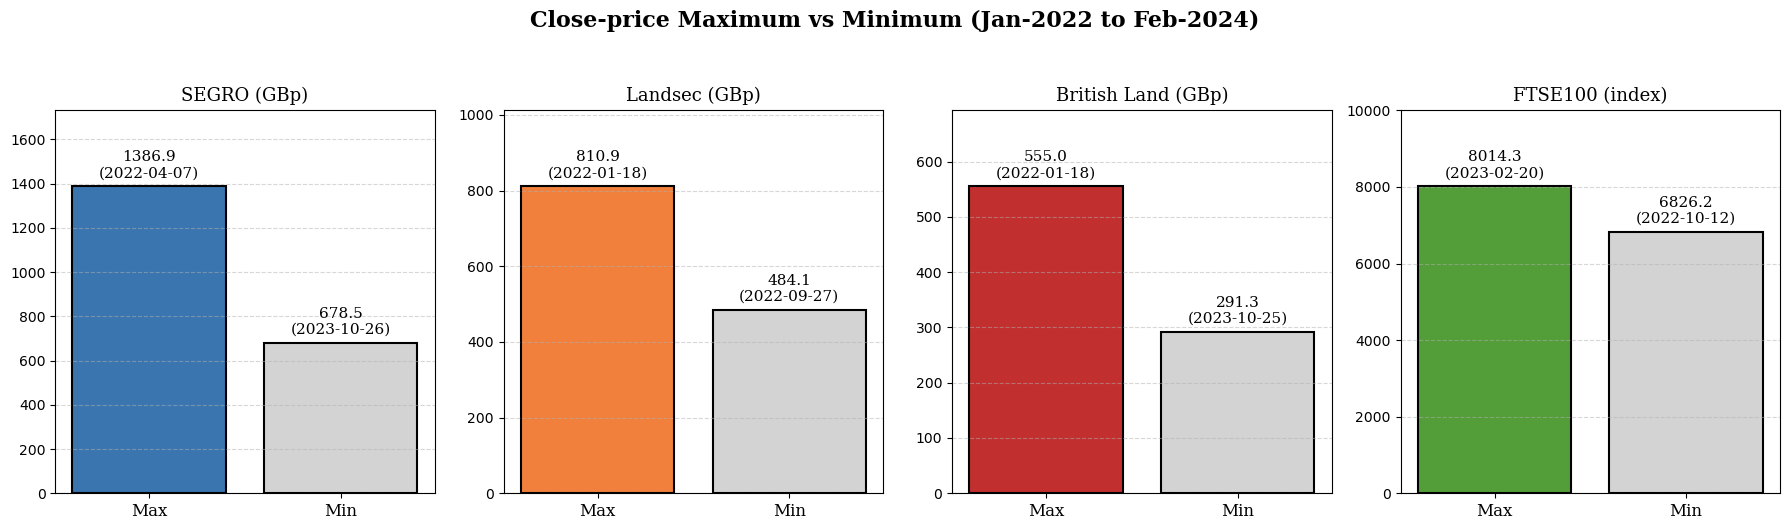

In [29]:
#CLOSE-PRICE MAXIMUM VS MINIMUM CHART
import matplotlib.pyplot as plt

# Define tickers 
plot_tickers = ['SGRO.L', 'LAND.L', 'BLND.L', '^FTSE']
titles = ['SEGRO (GBp)', 'Landsec (GBp)', 'British Land (GBp)', 'FTSE100 (index)']

# Add dark red color for British Land to maintain professional aesthetic
colors = ['#3b75af', '#f0803c', '#c22f2f', '#549e39'] 

# Create a 1x4 subplot grid, extend width to 18 to prevent text overlap
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Close-price Maximum vs Minimum (Jan-2022 to Feb-2024)', fontsize=16, fontname='serif', fontweight='bold', y=1.05)

for i, ticker in enumerate(plot_tickers):
    max_val = closing_prices[ticker].max()
    max_date = str(closing_prices[ticker].idxmax())[:10] 
    
    min_val = closing_prices[ticker].min()
    min_date = str(closing_prices[ticker].idxmin())[:10]
    
    ax = axes[i]
    # Plot bars: Max is colored, Min is greyed out for contrast
    bars = ax.bar(['Max', 'Min'], [max_val, min_val], color=[colors[i], '#d3d3d3'], edgecolor='black', linewidth=1.5)
    
    # Add Data Labels (Value on top, Date below)
    ax.text(0, max_val + (max_val * 0.02), f'{max_val:.1f}\n({max_date})', ha='center', va='bottom', fontsize=11, fontname='serif')
    ax.text(1, min_val + (max_val * 0.02), f'{min_val:.1f}\n({min_date})', ha='center', va='bottom', fontsize=11, fontname='serif')
    
    # Format subplot axes and titles
    ax.set_title(titles[i], fontname='serif', fontsize=13)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_ylim(0, max_val * 1.25) # Extend upper y-limit by 25% to prevent text clipping
    
    for label in ax.get_xticklabels():
        label.set_fontname('serif')
        label.set_fontsize(12)

plt.tight_layout()

# 1. Save the image
img_path = os.path.join(download_folder, "Max_Min_Chart.png")
plt.savefig(img_path, bbox_inches='tight', dpi=300)
print(f"Saved image: {img_path}")

# 2. Display the image
plt.show()

plt.close()

Saved image: /Users/rachelnguyen/Downloads/normalized_price.png


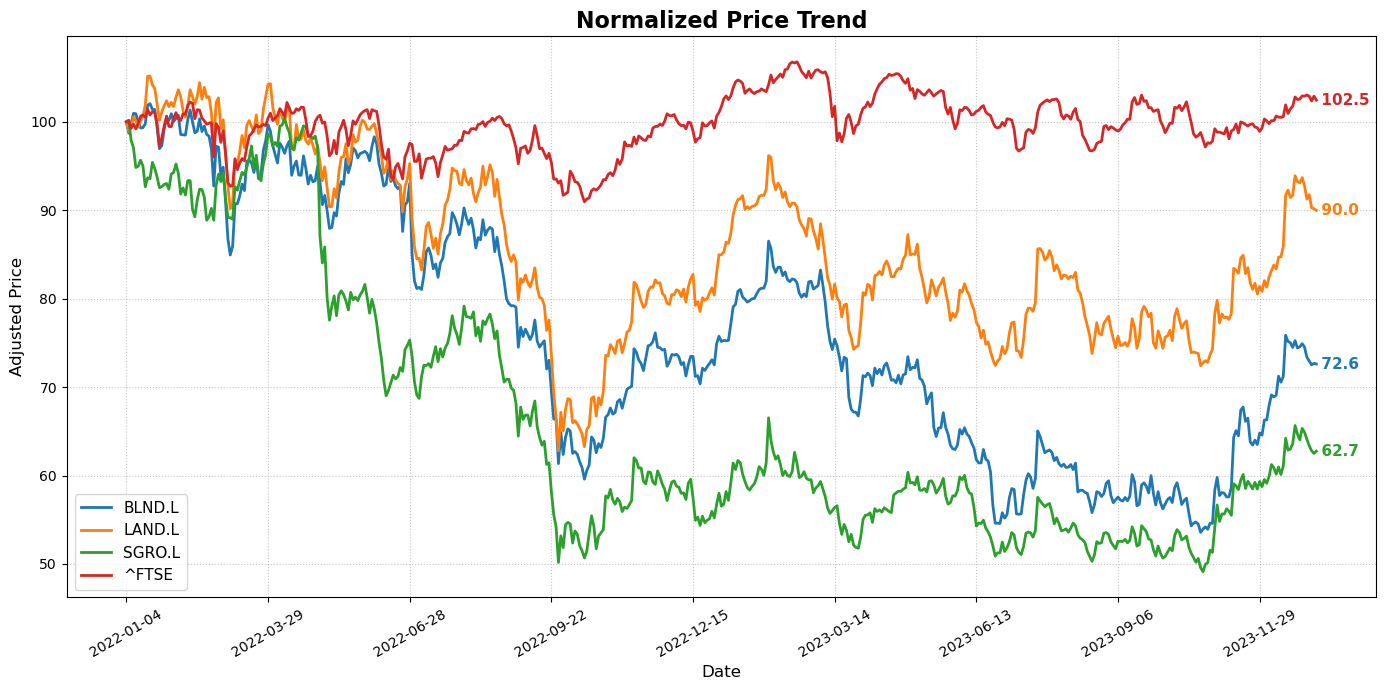

In [31]:
import matplotlib.ticker as mticker
# 1. LINE CHART (Price Trends - Normalized Base 100)
plt.figure(figsize=(14, 7))

for ticker_name in training_set.columns:
    # Normalize to Base 100
    normalized_price = (training_set[ticker_name] / training_set[ticker_name].iloc[0]) * 100
    line = plt.plot(normalized_price.index, normalized_price, label=ticker_name, linewidth=2)
    line_color = line[0].get_color()
    
    # Add Data Labels
    last_date = normalized_price.index[-1]
    last_value = normalized_price.iloc[-1]
    plt.text(last_date, last_value, f" {last_value:.1f}", color=line_color, fontweight='bold', va='center', fontsize=11)

plt.title('Normalized Price Trend', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Adjusted Price', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(nbins=10))
plt.xticks(rotation=30)
plt.tight_layout()

# 1. Save the image
img_path = os.path.join(download_folder, "normalized_price.png")
plt.savefig(img_path, bbox_inches='tight', dpi=300)
print(f"Saved image: {img_path}")

# 2. Display the image
plt.show()

plt.close()

In [32]:
companies = ['SGRO.L', 'BLND.L', 'LAND.L', '^FTSE'] 

# Calculate Returns
daily_returns = (training_set[companies] - training_set[companies].shift(1)) / training_set[companies].shift(1)
daily_returns = daily_returns.dropna()
all_returns = (training_set - training_set.shift(1)) / training_set.shift(1) # Used for regression later

# Group Close and Return data for each company
company_frames = []
for ticker in training_set.columns: # Includes SGRO, LAND, BLND, and FTSE
    df_temp = pd.DataFrame({
        'Close': training_set[ticker],
        'Return': all_returns[ticker]
    })
    company_frames.append(df_temp)

# Concatenate dataframes using company names as multi-level headers
close_return_df = pd.concat(company_frames, axis=1, keys=training_set.columns)

# Drop the first row (which contains NaN for returns)
close_return_df = close_return_df.dropna()

# Display the first 5 rows in the console for quick verification
print(close_return_df.head().round(4))

# Export the full table to an Excel file for the Report's Appendix
close_return_df.to_excel("Companies_Close_Return.xlsx")
print("-> Full table successfully saved to 'Companies_Close_Return.xlsx'")


Ticker        BLND.L            LAND.L             SGRO.L              ^FTSE  \
               Close  Return     Close  Return      Close  Return      Close   
Date                                                                           
2022-01-05  536.8184 -0.0128  762.6435 -0.0109  1383.2577  0.0014  7516.8999   
2022-01-06  542.2046  0.0100  766.8315  0.0055  1352.3079 -0.0224  7450.3999   
2022-01-07  548.9872  0.0125  775.2079  0.0109  1340.8265 -0.0085  7485.2998   
2022-01-10  548.7876 -0.0004  771.8175 -0.0044  1309.8766 -0.0231  7445.2998   
2022-01-11  543.6010 -0.0095  766.4327 -0.0070  1311.8733  0.0015  7491.3999   

Ticker              
            Return  
Date                
2022-01-05  0.0016  
2022-01-06 -0.0088  
2022-01-07  0.0047  
2022-01-10 -0.0053  
2022-01-11  0.0062  
-> Full table successfully saved to 'Companies_Close_Return.xlsx'
Saved image: /Users/rachelnguyen/Downloads/Close_Return.png


<Figure size 640x480 with 0 Axes>

In [33]:
#DESCRIPTIVE STATISTICS

# 1. Extract the Close price for Segro from the Training set
segro_close = training_set['SGRO.L']

# 2. Create a new DataFrame 
shift_demonstration = pd.DataFrame({
    '1. Close': segro_close,
    '2. Return': (segro_close - segro_close.shift(1)) / segro_close.shift(1)
})

print("SEGRO DAILY RETURNS")
print(shift_demonstration.head())

SEGRO DAILY RETURNS
               1. Close  2. Return
Date                              
2022-01-04  1381.260864        NaN
2022-01-05  1383.257690   0.001446
2022-01-06  1352.307861  -0.022375
2022-01-07  1340.826538  -0.008490
2022-01-10  1309.876587  -0.023083


In [34]:
# Statistical Metrics Table
for ticker in training_set.columns:
    # Extract data for this specific ticker and drop the first NaN row
    company_return = all_returns[ticker].dropna()
    
    # Calculate the required statistics
    mean_val = company_return.mean()
    median_val = company_return.median()
    variance_val = company_return.var()  
    std_val = company_return.std()
    sharpe_ratio = mean_val / std_val if std_val != 0 else 0
    
    # Print results 
    print(f"\nFINANCIAL METRICS FOR: {ticker}")
    print(f"  - Mean:         {mean_val:.6f}")
    print(f"  - Median:                 {median_val:.6f}")
    print(f"  - Sample Variance:        {variance_val:.8f}")
    print(f"  - Sample Standard Deviation:     {std_val:.6f}")
    print(f"  - Return to Risk (Sharpe Ratio): {sharpe_ratio:.6f}")
    print(f"  - Analyzed Sample Size (Days):   {len(company_return)}")
    print("-" * 45)


FINANCIAL METRICS FOR: BLND.L
  - Mean:         -0.000430
  - Median:                 -0.000350
  - Sample Variance:        0.00041083
  - Sample Standard Deviation:     0.020269
  - Return to Risk (Sharpe Ratio): -0.021219
  - Analyzed Sample Size (Days):   504
---------------------------------------------

FINANCIAL METRICS FOR: LAND.L
  - Mean:         -0.000033
  - Median:                 -0.000325
  - Sample Variance:        0.00035457
  - Sample Standard Deviation:     0.018830
  - Return to Risk (Sharpe Ratio): -0.001746
  - Analyzed Sample Size (Days):   504
---------------------------------------------

FINANCIAL METRICS FOR: SGRO.L
  - Mean:         -0.000716
  - Median:                 -0.001658
  - Sample Variance:        0.00041730
  - Sample Standard Deviation:     0.020428
  - Return to Risk (Sharpe Ratio): -0.035068
  - Analyzed Sample Size (Days):   504
---------------------------------------------

FINANCIAL METRICS FOR: ^FTSE
  - Mean:         0.000088
  - Median:  

Saved image: /Users/rachelnguyen/Downloads/Histogram_SGRO.L.png


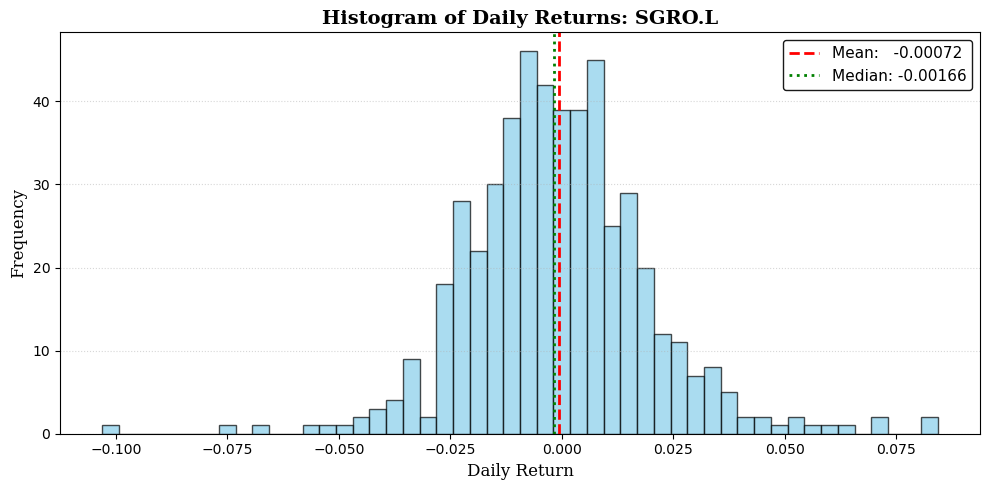

Saved image: /Users/rachelnguyen/Downloads/Histogram_BLND.L.png


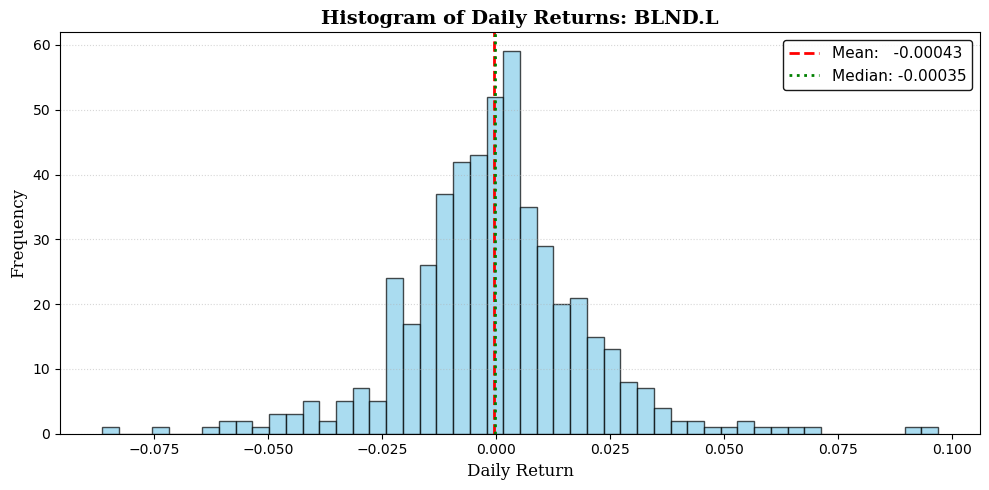

Saved image: /Users/rachelnguyen/Downloads/Histogram_LAND.L.png


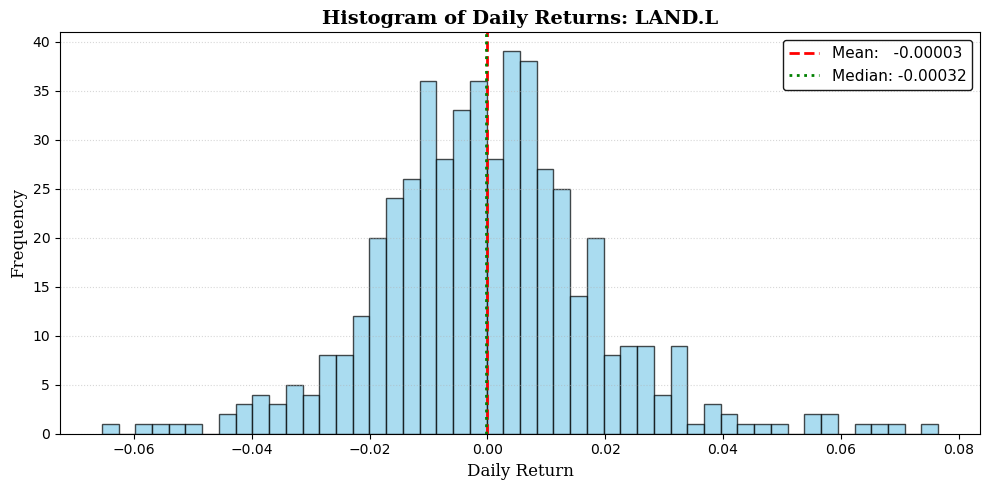

Saved image: /Users/rachelnguyen/Downloads/Histogram_FTSE.png


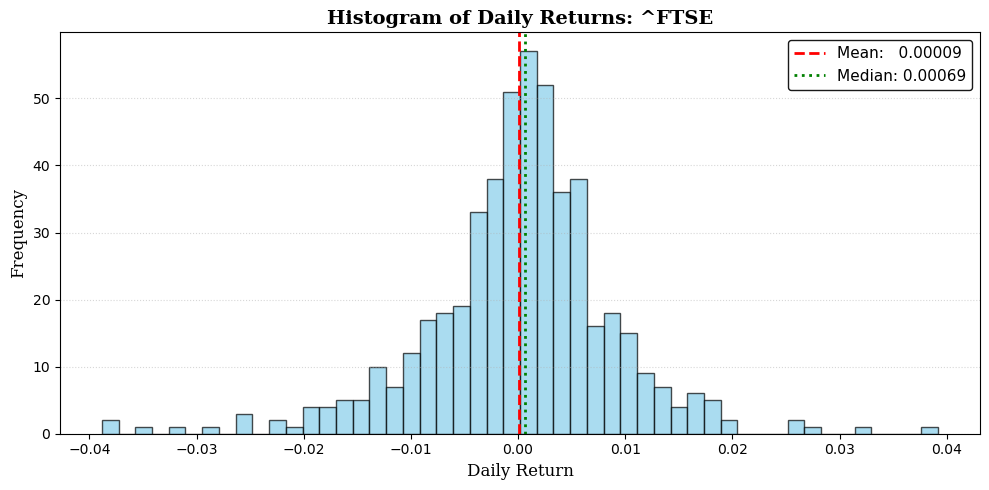

In [51]:
#Histogram
companies = ['SGRO.L', 'BLND.L', 'LAND.L','^FTSE']

for ticker in companies:
    plt.figure(figsize=(10, 5))
    clean_data = daily_returns[ticker].dropna()
    
    plt.hist(clean_data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Calculate Mean & Median
    mean_val = clean_data.mean()
    median_val = clean_data.median()
    
    # Plot Mean and Median lines to analyze skewness
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean:   {mean_val:.5f}')
    plt.axvline(median_val, color='green', linestyle='dotted', linewidth=2, label=f'Median: {median_val:.5f}')
    
    plt.title(f'Histogram of Daily Returns: {ticker}', fontsize=14, fontweight='bold', fontname='serif')
    plt.xlabel('Daily Return', fontname='serif', fontsize=12)
    plt.ylabel('Frequency', fontname='serif', fontsize=12)
    plt.legend(fontsize=11, loc='upper right', framealpha=0.9, edgecolor='black')
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()

# save the image 
    safe_ticker = ticker.replace('^', '')
    file_name = f"Histogram_{safe_ticker}.png"
    img_path = os.path.join(download_folder, file_name)
    
    plt.savefig(img_path, bbox_inches='tight', dpi=300)
    print(f"Saved image: {img_path}")

    plt.show()
    plt.close()

Saved image: /Users/rachelnguyen/Downloads/Moving_average_BLND.L.png


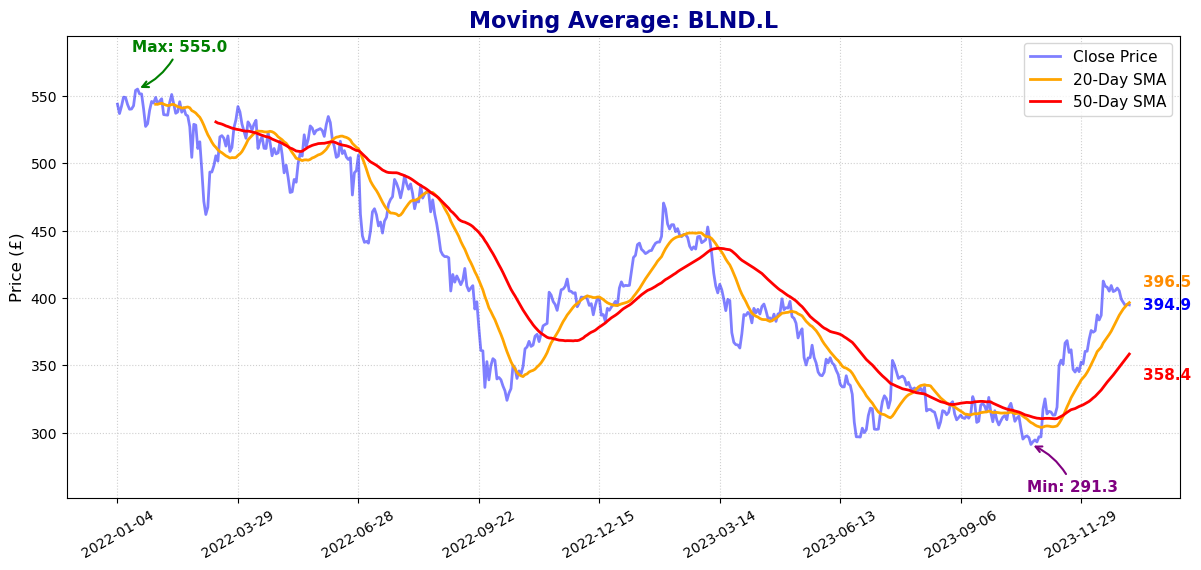

Saved image: /Users/rachelnguyen/Downloads/Moving_average_LAND.L.png


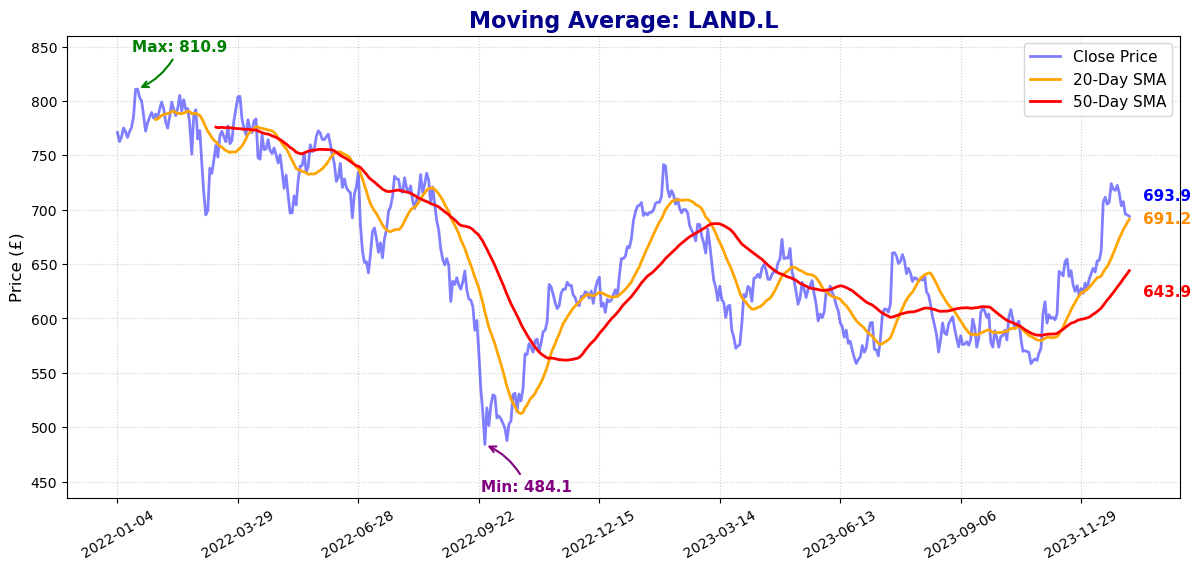

Saved image: /Users/rachelnguyen/Downloads/Moving_average_SGRO.L.png


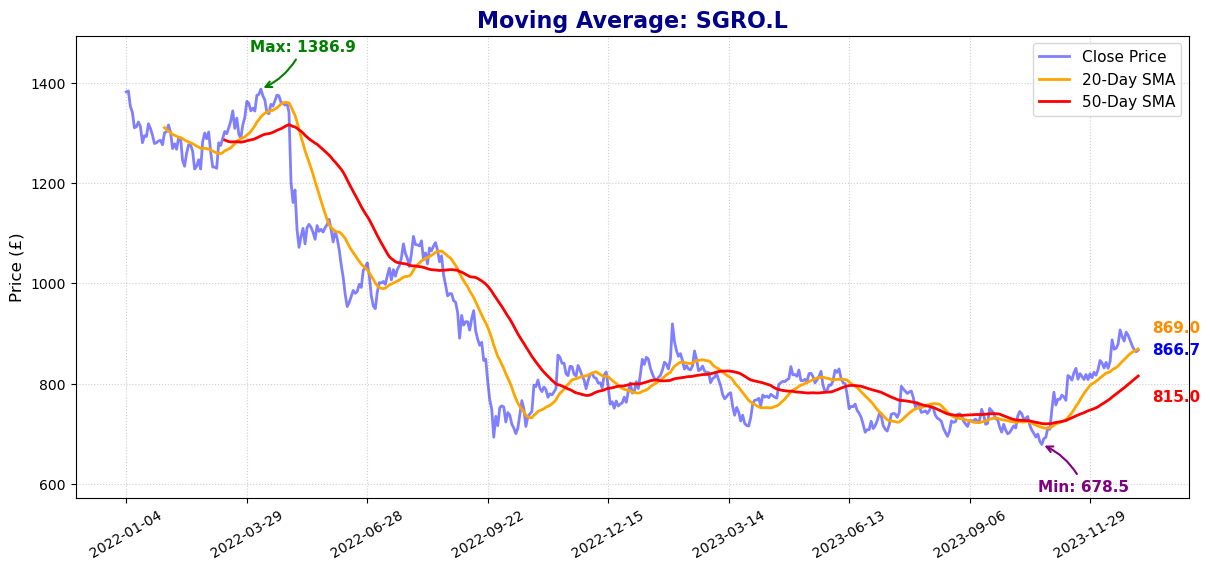

Saved image: /Users/rachelnguyen/Downloads/Moving_average_FTSE.png


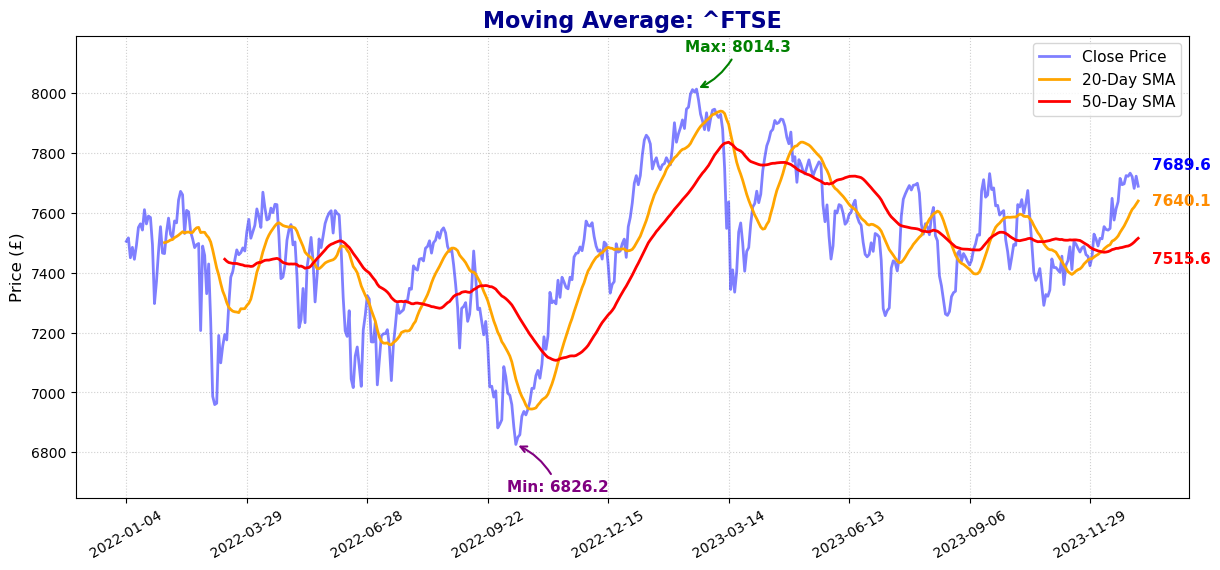

In [52]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

tickers = training_set.columns

for ticker in tickers:
    plt.figure(figsize=(14, 6)) 
    
    # 1. Calculate SMA
    short_sma = training_set[ticker].rolling(window=20).mean()
    long_sma = training_set[ticker].rolling(window=50).mean()
    
    # 2. Draw 3 lines
    plt.plot(training_set.index, training_set[ticker], label='Close Price', color='blue', alpha=0.5, linewidth=2)
    plt.plot(short_sma.index, short_sma, label='20-Day SMA', color='orange', linewidth=2)
    plt.plot(long_sma.index, long_sma, label='50-Day SMA', color='red', linewidth=2)
    
    plt.margins(y=0.15) 
    
    # 3. FIND MAXIMUM AND MINIMUM VALUES
    max_price = training_set[ticker].max()
    max_date = training_set[ticker].idxmax()
    
    min_price = training_set[ticker].min()
    min_date = training_set[ticker].idxmin()
    
    plt.annotate(f"Max: {max_price:.1f}", xy=(max_date, max_price), 
                 xytext=(30, 25), textcoords='offset points', ha='center', va='bottom',
                 color='green', fontweight='bold', fontsize=11,
                 arrowprops=dict(arrowstyle='->', color='green', lw=1.5, connectionstyle="arc3,rad=-0.2"))
                 
    plt.annotate(f"Min: {min_price:.1f}", xy=(min_date, min_price), 
                 xytext=(30, -25), textcoords='offset points', ha='center', va='top',
                 color='purple', fontweight='bold', fontsize=11,
                 arrowprops=dict(arrowstyle='->', color='purple', lw=1.5, connectionstyle="arc3,rad=0.2"))
    
    # 4. DATA LABELS
    last_date = training_set.index[-1]
    
    last_values = [
        (training_set[ticker].iloc[-1], 'blue', 'Close'),
        (short_sma.iloc[-1], 'darkorange', 'SMA20'),
        (long_sma.iloc[-1], 'red', 'SMA50')
    ]
    
    last_values.sort(key=lambda x: x[0])
    offsets = [-15, 0, 15] 
    
    for i in range(3):
        val, color, name = last_values[i]
        if not pd.isna(val): 
            plt.annotate(f"{val:.1f}", xy=(last_date, val), 
                         xytext=(10, offsets[i]), textcoords='offset points',
                         color=color, fontweight='bold', va='center', fontsize=11)
    
    # 5. FORMAT 
    plt.title(f'Moving Average: {ticker}', fontsize=16, fontweight='bold', color='darkblue')
    plt.ylabel('Price (£)', fontsize=12)
    plt.legend(loc='upper right', fontsize=11) 
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(nbins=10))
    plt.xticks(rotation=30)
    
    plt.subplots_adjust(right=0.92)
    
# save the image 
    safe_ticker = ticker.replace('^', '')
    file_name = f"Moving_average_{safe_ticker}.png"
    img_path = os.path.join(download_folder, file_name)
    
    plt.savefig(img_path, bbox_inches='tight', dpi=300)
    print(f"Saved image: {img_path}")

    plt.show()
    plt.close()

Saved image: /Users/rachelnguyen/Downloads/Forecasting_SGRO.L.png


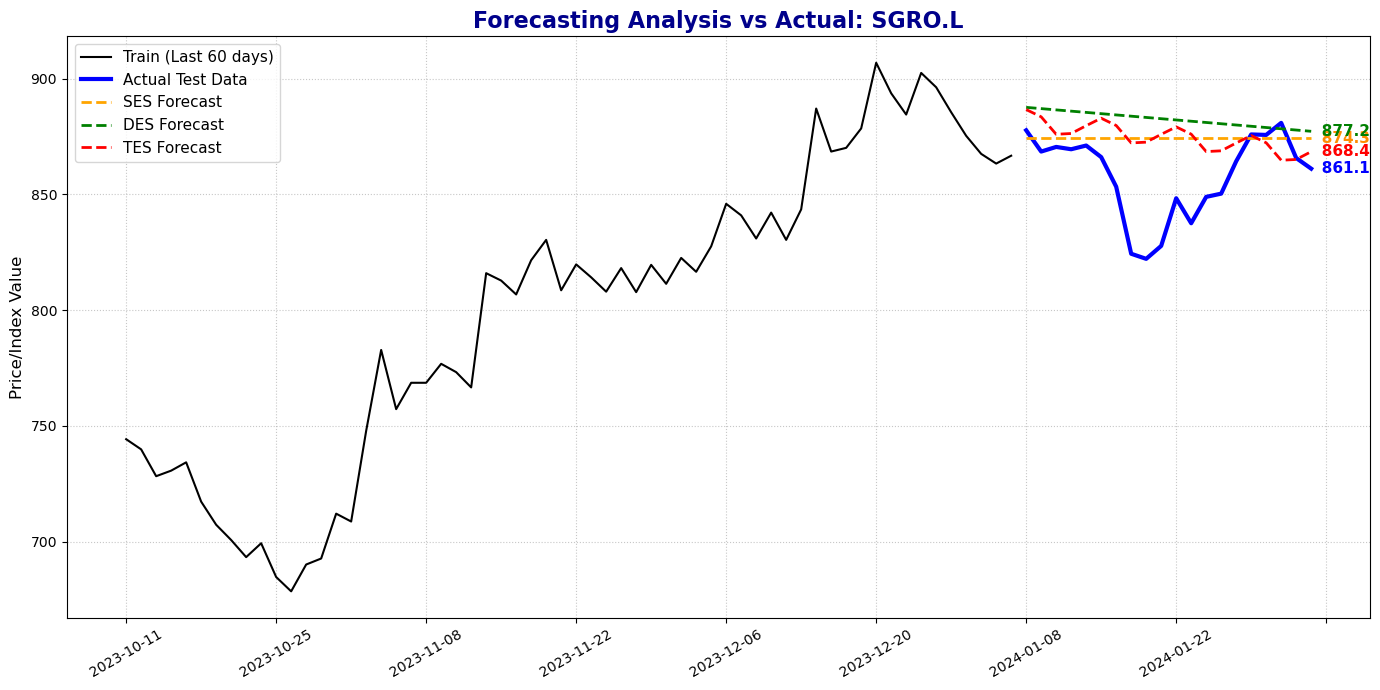

Saved image: /Users/rachelnguyen/Downloads/Forecasting_BLND.L.png


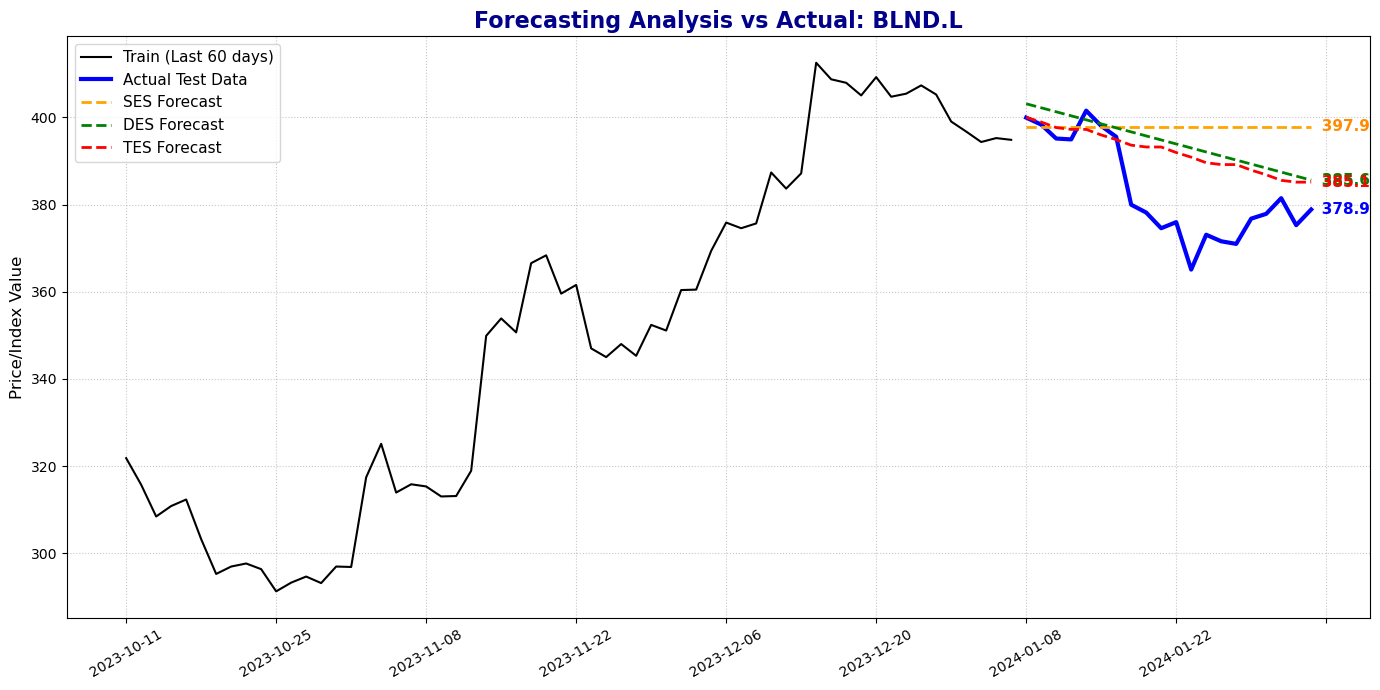

Saved image: /Users/rachelnguyen/Downloads/Forecasting_LAND.L.png


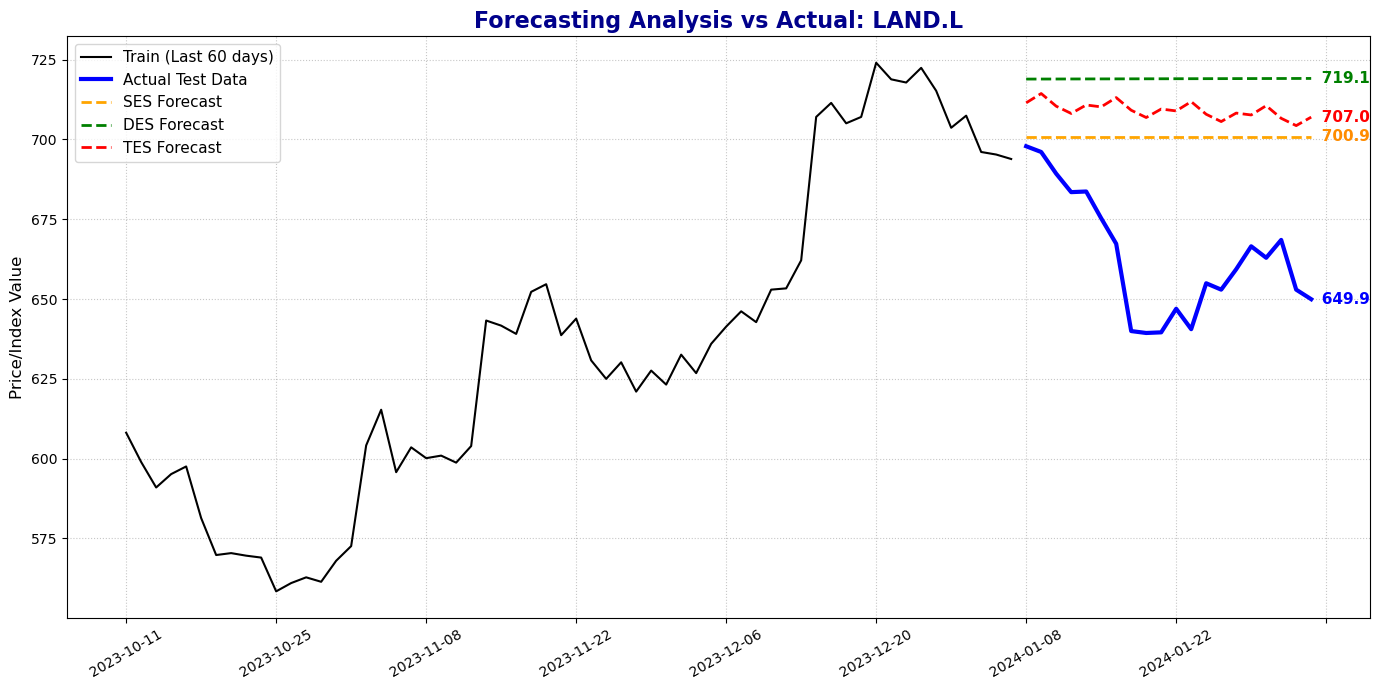

Saved image: /Users/rachelnguyen/Downloads/Forecasting_FTSE.png


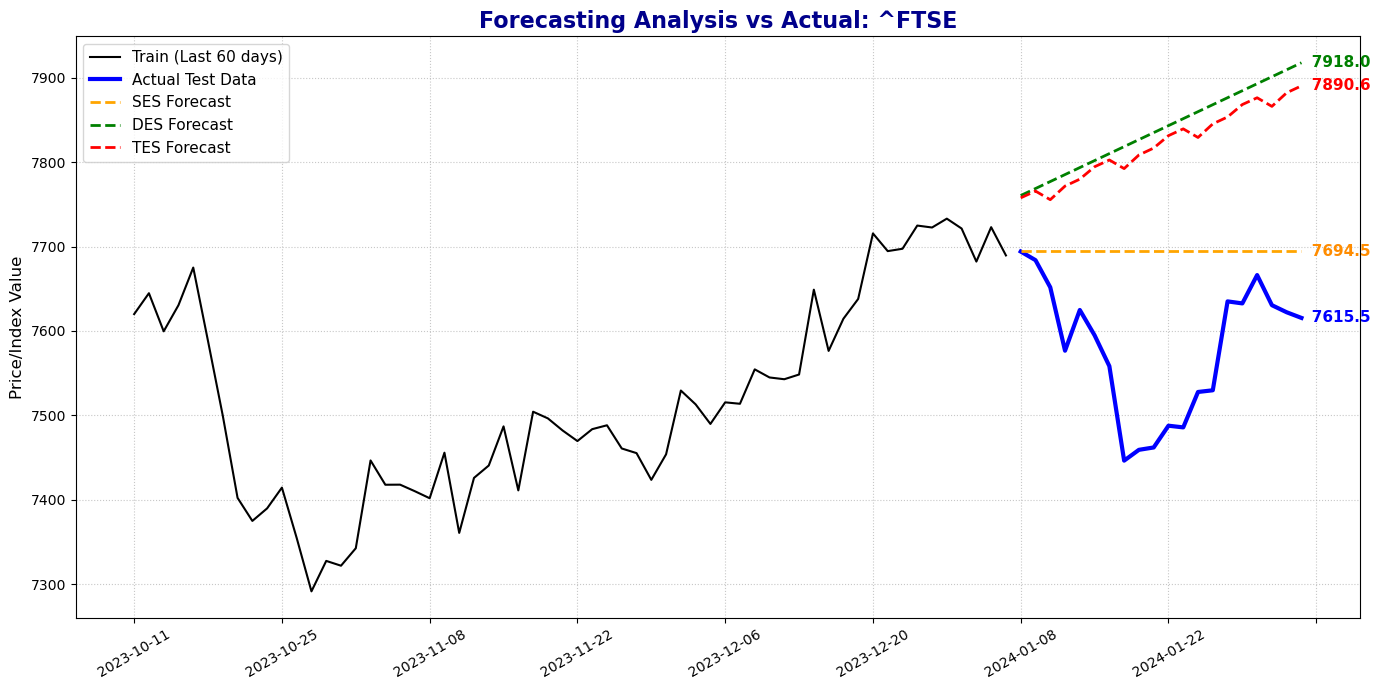


 FORECAST ACCURACY COMPARISON TABLE 
                 MAE       MSE    RMSE
Asset  Model                          
SGRO.L SES     17.61    580.98   24.10
       DES     24.69    924.20   30.40
       TES     18.89    606.92   24.64
BLND.L SES     15.35    342.85   18.52
       DES     11.41    189.26   13.76
       TES      9.71    149.25   12.22
LAND.L SES     37.52   1753.38   41.87
       DES     55.64   3442.65   58.67
       TES     45.77   2403.54   49.03
^FTSE  SES    115.20  19255.61  138.76
       DES    260.06  76289.44  276.21
       TES    242.31  66626.75  258.12


In [60]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

accuracy_metrics = []

analysis_assets = ['SGRO.L', 'BLND.L', 'LAND.L', '^FTSE']

for company in analysis_assets:
    train_close = training_set[company].ffill()
    test_close = test_set[company]
    
    ses_model = SimpleExpSmoothing(train_close).fit(smoothing_level=0.2, optimized=False)
    ses_forecast = ses_model.forecast(steps=20)
    
    des_model = ExponentialSmoothing(train_close, trend='add', seasonal=None).fit(smoothing_level=0.2, smoothing_trend=0.2, optimized=False)
    des_forecast = des_model.forecast(steps=20)
    
    tes_model = ExponentialSmoothing(train_close, trend='add', seasonal='add', seasonal_periods=5).fit(smoothing_level=0.2, smoothing_trend=0.2, smoothing_seasonal=0.2, optimized=False)
    tes_forecast = tes_model.forecast(steps=20)
    
    ses_mse, des_mse, tes_mse = MSE(test_close, ses_forecast), MSE(test_close, des_forecast), MSE(test_close, tes_forecast)
    accuracy_metrics.extend([
        {'Asset': company, 'Model': 'SES', 'MAE': MAE(test_close, ses_forecast), 'MSE': ses_mse, 'RMSE': np.sqrt(ses_mse)},
        {'Asset': company, 'Model': 'DES', 'MAE': MAE(test_close, des_forecast), 'MSE': des_mse, 'RMSE': np.sqrt(des_mse)},
        {'Asset': company, 'Model': 'TES', 'MAE': MAE(test_close, tes_forecast), 'MSE': tes_mse, 'RMSE': np.sqrt(tes_mse)}
    ])
    
    plt.figure(figsize=(14, 7))
    plt.plot(train_close.index[-60:], train_close.iloc[-60:], label='Train (Last 60 days)', color='black', linewidth=1.5)
    plt.plot(test_close.index, test_close, label='Actual Test Data', color='blue', linewidth=3)
    
    plt.plot(test_close.index, ses_forecast, label='SES Forecast', color='orange', linestyle='--', linewidth=2)
    plt.plot(test_close.index, des_forecast, label='DES Forecast', color='green', linestyle='--', linewidth=2)
    plt.plot(test_close.index, tes_forecast, label='TES Forecast', color='red', linestyle='--', linewidth=2)
    
    plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(nbins=10))
    plt.xticks(rotation=30)
    
    last_date = test_close.index[-1]
    plt.text(last_date, test_close.iloc[-1], f"  {test_close.iloc[-1]:.1f}", color='blue', fontweight='bold', va='center', fontsize=11)
    plt.text(last_date, ses_forecast.iloc[-1], f"  {ses_forecast.iloc[-1]:.1f}", color='darkorange', fontweight='bold', va='center', fontsize=11)
    plt.text(last_date, des_forecast.iloc[-1], f"  {des_forecast.iloc[-1]:.1f}", color='green', fontweight='bold', va='center', fontsize=11)
    plt.text(last_date, tes_forecast.iloc[-1], f"  {tes_forecast.iloc[-1]:.1f}", color='red', fontweight='bold', va='center', fontsize=11)
    
    plt.title(f"Forecasting Analysis vs Actual: {company}", fontsize=16, fontweight='bold', color='darkblue')
    plt.ylabel("Price/Index Value", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(fontsize=11, loc='upper left')
    plt.tight_layout()


    # save the image 
    safe_ticker = company.replace('^', '')
    file_name = f"Forecasting_{safe_ticker}.png"
    img_path = os.path.join(download_folder, file_name)
    
    plt.savefig(img_path, bbox_inches='tight', dpi=300)
    print(f"Saved image: {img_path}")

    plt.show()
    plt.close()

print("\n" + "="*60)
print(" FORECAST ACCURACY COMPARISON TABLE ")
print("="*60)
metrics_df = pd.DataFrame(accuracy_metrics).set_index(['Asset', 'Model']).round(2)
print(metrics_df)


CORRELATION & REGRESSION

--- REGRESSION MODEL SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:                 SGRO.L   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     1251.
Date:                Fri, 10 Jul 2026   Prob (F-statistic):          4.25e-231
Time:                        23:59:48   Log-Likelihood:                -2844.1
No. Observations:                 501   AIC:                             5696.
Df Residuals:                     497   BIC:                             5713.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

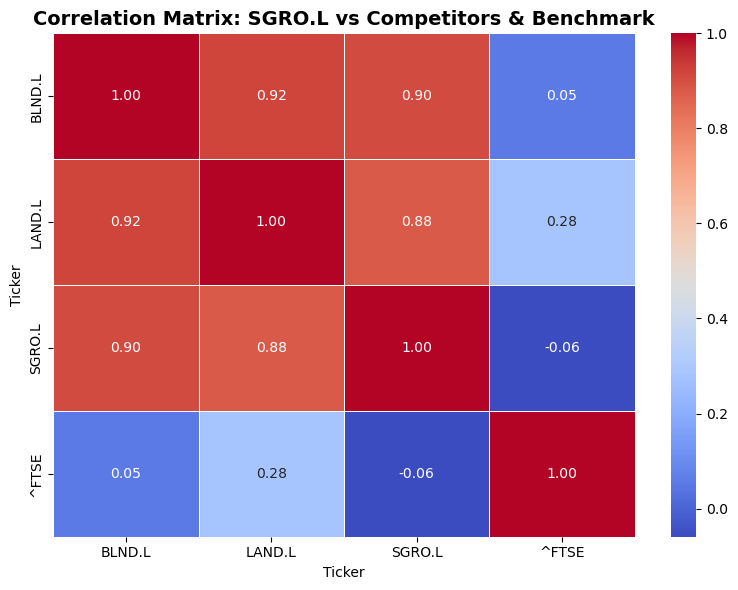

In [65]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")

print("CORRELATION & REGRESSION")

tickers = ['SGRO.L', 'BLND.L', 'LAND.L', '^FTSE']
data = yf.download(tickers, start="2022-01-01", end="2024-01-01", progress=False)
df_prices = data['Close'].dropna()

# DRAW CORRELATION MATRIX)]
plt.figure(figsize=(8, 6))
correlation_matrix = df_prices.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: SGRO.L vs Competitors & Benchmark", fontweight='bold', fontsize=14)
plt.tight_layout()

# RUN MULTIPLE LINEAR REGRESSION
print("\n--- REGRESSION MODEL SUMMARY ---")

# Y: DEPENDENT VARIABLE
y = df_prices['SGRO.L']

# X: DEPENDENT VARIABLE
X = df_prices[['BLND.L', 'LAND.L', '^FTSE']]
X = sm.add_constant(X) 

model = sm.OLS(y, X).fit()
print(model.summary())

# save the image 
safe_ticker = ticker.replace('^', '')
file_name = f"Correlation_{safe_ticker}.png"
img_path = os.path.join(download_folder, file_name)
    
plt.savefig(img_path, bbox_inches='tight', dpi=300)
print(f"Saved image: {img_path}")

plt.show()
plt.close()

In [49]:
import statsmodels.api as sm

# 1. Define independent variables (X) and dependent variable (y)
independent_vars = ['BLND.L', 'LAND.L', '^FTSE']
dependent_var = 'SGRO.L'

# 2. Convert necessary columns to numeric (handling potential string issues)
all_returns[independent_vars] = all_returns[independent_vars].apply(pd.to_numeric, errors='coerce')
all_returns[dependent_var] = pd.to_numeric(all_returns[dependent_var], errors='coerce')

# 3. Drop rows with missing values in the selected columns
clean_df = all_returns.dropna(subset=independent_vars + [dependent_var])

# 4. Define X and y for the model
X = clean_df[independent_vars]
y = clean_df[dependent_var]

# 5. Add a constant for the intercept
X = sm.add_constant(X)

# 6. Fit the multiple linear regression model
initial_model = sm.OLS(y, X).fit()

# 7. Display initial regression summary
print(initial_model.summary())



                            OLS Regression Results                            
Dep. Variable:                 SGRO.L   R-squared:                       0.600
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                     249.6
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           5.65e-99
Time:                        22:57:59   Log-Likelihood:                 1477.0
No. Observations:                 504   AIC:                            -2946.
Df Residuals:                     500   BIC:                            -2929.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0006      0.001     -0.961      0.3

Saved image: /Users/rachelnguyen/Downloads/Multiple_linear.png


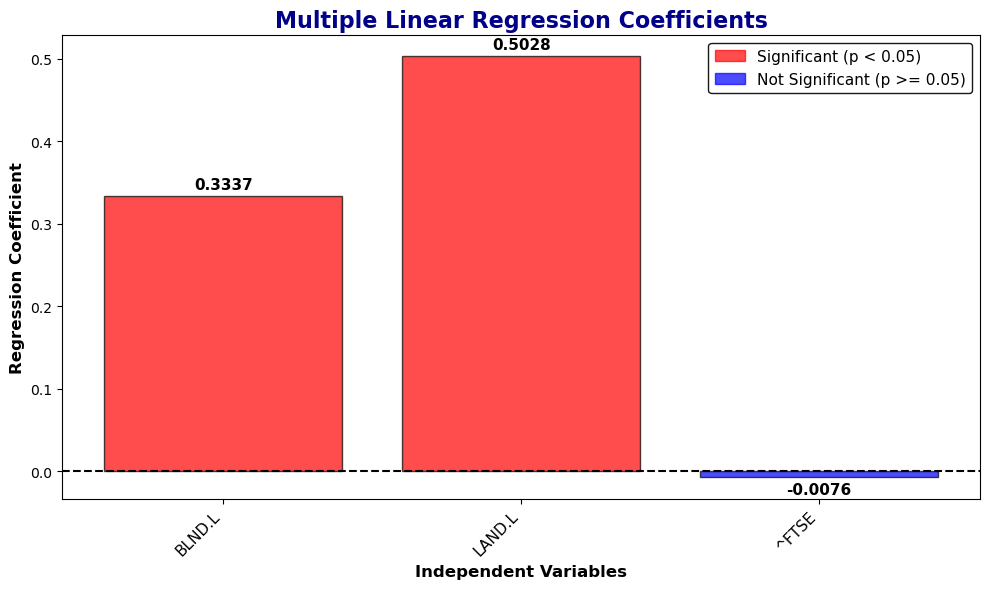

In [46]:
# MULTIPLE LINEAR REGRESSION 
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

coefficients = initial_model.params[1:] 
p_values = initial_model.pvalues[1:] 

colors = ['red' if p < 0.05 else 'blue' for p in p_values]

plt.figure(figsize=(10, 6))

bars = plt.bar(coefficients.index, coefficients.values, color=colors, alpha=0.7, edgecolor='black')
plt.axhline(0, color='black', linestyle='dashed', linewidth=1.5) # Đường mốc 0

# ADD DATA LABELS 
for bar in bars:
    yval = bar.get_height()
    # Nếu cột âm thì ghi số ở dưới, cột dương thì ghi số ở trên
    va_alignment = 'bottom' if yval >= 0 else 'top'
    y_offset = 0.01 * max(coefficients.abs()) if yval >= 0 else -0.01 * max(coefficients.abs())
    
    plt.text(bar.get_x() + bar.get_width()/2, yval + y_offset, 
             f"{yval:.4f}", ha='center', va=va_alignment, fontweight='bold', fontsize=11)

# Format 
plt.xlabel("Independent Variables", fontsize=12, fontweight='bold')
plt.ylabel("Regression Coefficient", fontsize=12, fontweight='bold')
plt.title("Multiple Linear Regression Coefficients", fontsize=16, fontweight='bold', color='darkblue')
plt.xticks(rotation=45, ha='right', fontsize=11)

red_patch = mpatches.Patch(color='red', alpha=0.7, label='Significant (p < 0.05)')
blue_patch = mpatches.Patch(color='blue', alpha=0.7, label='Not Significant (p >= 0.05)')
plt.legend(handles=[red_patch, blue_patch], loc='best', fontsize=11, framealpha=0.9, edgecolor='black')

plt.tight_layout()

# 1. Save the image
img_path = os.path.join(download_folder, "Multiple_linear.png")
plt.savefig(img_path, bbox_inches='tight', dpi=300)
print(f"Saved image: {img_path}")

# 2. Display the image
plt.show()

plt.close()

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Calculate the Variance Inflation Factor (VIF) for each independent variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 2. Display the VIF values
print(vif_data)

  Variable       VIF
0    const  1.002403
1   BLND.L  5.604009
2   LAND.L  5.945726
3    ^FTSE  1.489322


Removing '^FTSE' with p-value 0.9238

Final Regression Model Summary:
                            OLS Regression Results                            
Dep. Variable:                 SGRO.L   R-squared:                       0.600
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     375.2
Date:                Sat, 11 Jul 2026   Prob (F-statistic):          2.59e-100
Time:                        00:13:10   Log-Likelihood:                 1477.0
No. Observations:                 504   AIC:                            -2948.
Df Residuals:                     501   BIC:                            -2935.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

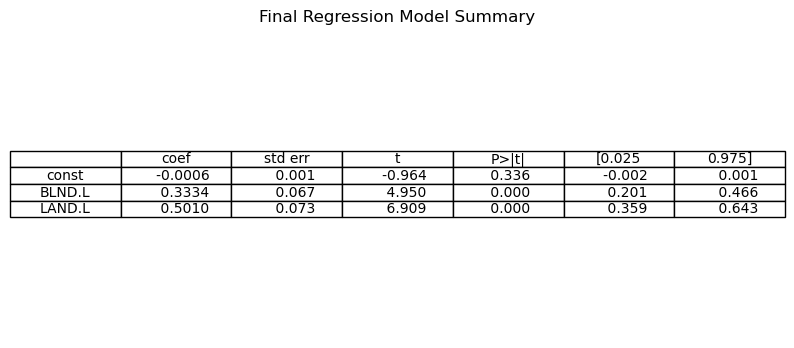

In [67]:
# 1. Align X and y indices and fit the final model
# Assuming 'y' and 'clean_df' are already defined
y = clean_df['SGRO.L']
current_vars = ['BLND.L', 'LAND.L', '^FTSE']

while True:
    # Get X and add a constant, ensuring index alignment with y
    X_subset = clean_df[current_vars]
    X_with_const = sm.add_constant(X_subset)
    
    # Ensure X and y indices are perfectly aligned
    X_with_const = X_with_const.loc[y.index]
    
    # Fit the model
    model = sm.OLS(y, X_with_const).fit()
    
    # Get p-values, excluding the intercept ("const")
    p_values = model.pvalues.drop("const")
    max_p_var = p_values.idxmax()
    max_p_value = p_values.max()
    
    # Stop if all p-values are below 0.05
    if max_p_value < 0.05:
        break
        
    # Remove the least significant variable
    current_vars.remove(max_p_var)
    print(f"Removing '{max_p_var}' with p-value {max_p_value:.4f}")

# Display the final regression summary
print("\nFinal Regression Model Summary:")
print(model.summary())

# Convert the regression results into a DataFrame
results_summary = model.summary().tables[1]
results_df = pd.DataFrame(results_summary.data[1:], columns=results_summary.data[0])

# Draw the table as an image
plt.figure(figsize=(10, 4))
plt.axis('off')  # Turn off the axis
plt.table(cellText=results_df.values, 
          colLabels=results_df.columns, 
          cellLoc='center', 
          loc='center')
plt.title("Final Regression Model Summary")

# Save the table as an image
img_path = os.path.join(download_folder, "Regression_result.png")
plt.savefig(img_path, bbox_inches='tight', dpi=300)
print(f"Saved image: {img_path}")

plt.show()
plt.close()